 Import All Libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (EarlyStopping,
                                        ModelCheckpoint)

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded!")

TensorFlow version: 2.20.0
All libraries loaded!


 Load the Dataset

In [ ]:
# Load MNIST directly from keras
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Dataset loaded!")
print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Testing images: ", X_test.shape)
print("Testing labels: ", y_test.shape)

Dataset loaded!
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images:  (10000, 28, 28)
Testing labels:  (10000,)


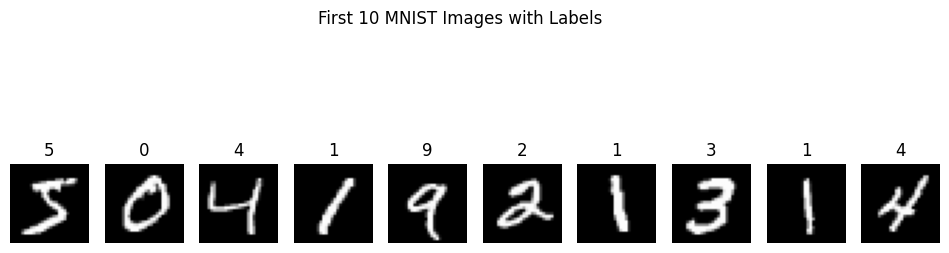

In [ ]:
# Display the first 10 images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train_full[i], cmap='gray')
    plt.title(str(y_train_full[i]))
    plt.axis('off')
plt.suptitle('First 10 MNIST Images with Labels')
plt.show()

In [ ]:
# Understand the data
print("Pixel value range:", X_train_full.min(), "to", X_train_full.max())
print("Number of classes:", len(np.unique(y_train_full)))
print("Classes:", np.unique(y_train_full))

print("\nClass distribution:")
for digit in range(10):
    count = (y_train_full == digit).sum()
    print(f"  Digit {digit}: {count} images")

Pixel value range: 0 to 255
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]

Class distribution:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


 Preprocess the Data

In [ ]:
# Step 1 — Normalize pixel values from 0-255 down to 0-1
X_train_full = X_train_full / 255.0
X_test       = X_test       / 255.0

print("Pixel range after normalization:")
print("Min:", X_train_full.min(), " Max:", X_train_full.max())

Pixel range after normalization:
Min: 0.0  Max: 1.0


In [ ]:
# Step 2 — Flatten each 28×28 image into a single row of 784 numbers
X_train_full = X_train_full.reshape(-1, 784)
X_test       = X_test.reshape(-1, 784)

print("Shape after flattening:")
print("Training:", X_train_full.shape)
print("Testing: ", X_test.shape)

Shape after flattening:
Training: (60000, 784)
Testing:  (10000, 784)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Step 3 — Split training data into train and validation
# Test set already comes separately from keras
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

print("Training samples:   ", X_train.shape[0])
print("Validation samples: ", X_val.shape[0])
print("Testing samples:    ", X_test.shape[0])

Training samples:    54000
Validation samples:  6000
Testing samples:     10000


Build the Four MLP Models

In [ ]:
def build_model(use_dropout, use_batchnorm, model_name):

    model = keras.Sequential(name=model_name)

    # Hidden Layer 1
    model.add(layers.Dense(256, activation='relu', input_shape=(784,)))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.3))

    # Hidden Layer 2
    model.add(layers.Dense(128, activation='relu'))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.3))

    # Hidden Layer 3
    model.add(layers.Dense(64, activation='relu'))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    if use_dropout:
        model.add(layers.Dropout(0.3))

    # Output Layer
    # 10 neurons = one for each digit 0-9
    # Softmax = converts outputs into probabilities that add up to 1
    model.add(layers.Dense(10, activation='softmax'))

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

print("Function ready!")

Function ready!


In [ ]:
# Build all four models
model_A = build_model(use_dropout=False, use_batchnorm=False, model_name='Model_A_Plain')
model_B = build_model(use_dropout=True,  use_batchnorm=False, model_name='Model_B_Dropout')
model_C = build_model(use_dropout=False, use_batchnorm=True,  model_name='Model_C_BatchNorm')
model_D = build_model(use_dropout=True,  use_batchnorm=True,  model_name='Model_D_Both')

print("All four models built!")
print("\nModel A — Plain MLP")
model_A.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


All four models built!

Model A — Plain MLP


Model: "Model_A_Plain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Model D — Dropout + Batch Normalization")
model_D.summary()

Model D — Dropout + Batch Normalization


Model: "Model_D_Both"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,554 (955.29 KB)

 Trainable params: 243,658 (951.79 KB)

 Non-trainable params: 896 (3.50 KB)

Train All Four Models

In [ ]:
# Set up callbacks — these run automatically during training

# EarlyStopping — stops training if val_loss doesn't improve for 5 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint — saves the best model automatically
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("Callbacks ready!")

Callbacks ready!


Model A

In [ ]:
# Dictionary to store results
training_results = {}

# ── Model A ──────────────────────────────────────────
print("=" * 45)
print("Training Model A — Plain MLP")
print("=" * 45)
start = time.time()

history_A = model_A.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

time_A = time.time() - start
training_results['Model A'] = {
    'history': history_A,
    'time': time_A
}
print(f"Model A done! Time: {time_A:.1f} seconds\n")

Training Model A — Plain MLP
Epoch 1/50
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8631 - loss: 0.4701
Epoch 1: val_accuracy improved from None to 0.95967, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.9262 - loss: 0.2513 - val_accuracy: 0.9597 - val_loss: 0.1361
Epoch 2/50
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9691 - loss: 0.1021
Epoch 2: val_accuracy improved from 0.95967 to 0.96633, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9699 - loss: 0.0985 - val_accuracy: 0.9663 - val_loss: 0.1065
Epoch 3/50
835/844 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9790 - loss: 0.0670
Epoch 3: val_accuracy improved from 0.96633 to 0.97100, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9

Model B

In [ ]:
# ── Model B ──────────────────────────────────────────
print("=" * 45)
print("Training Model B — MLP + Dropout")
print("=" * 45)
start = time.time()

history_B = model_B.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

time_B = time.time() - start
training_results['Model B'] = {
    'history': history_B,
    'time': time_B
}
print(f"Model B done! Time: {time_B:.1f} seconds\n")

Training Model B — MLP + Dropout
Epoch 1/50
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7479 - loss: 0.7741
Epoch 1: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8649 - loss: 0.4410 - val_accuracy: 0.9518 - val_loss: 0.1659
Epoch 2/50
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9423 - loss: 0.2017
Epoch 2: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9461 - loss: 0.1905 - val_accuracy: 0.9662 - val_loss: 0.1217
Epoch 3/50
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9587 - loss: 0.1439
Epoch 3: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9583 - loss: 0.1462 - val_accuracy: 0.9652 - val_loss: 0.1168
Epoch 4/50
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9649 - loss: 0.1237
Epoch 4: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9644 - loss: 

Modle C

In [ ]:
# ── Model C ──────────────────────────────────────────
print("=" * 45)
print("Training Model C — MLP + Batch Normalization")
print("=" * 45)
start = time.time()

history_C = model_C.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

time_C = time.time() - start
training_results['Model C'] = {
    'history': history_C,
    'time': time_C
}
print(f"Model C done! Time: {time_C:.1f} seconds\n")

Training Model C — MLP + Batch Normalization
Epoch 1/50
837/844 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8854 - loss: 0.3829
Epoch 1: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9344 - loss: 0.2196 - val_accuracy: 0.9582 - val_loss: 0.1401
Epoch 2/50
836/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9680 - loss: 0.1024
Epoch 2: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9688 - loss: 0.0989 - val_accuracy: 0.9712 - val_loss: 0.1064
Epoch 3/50
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9781 - loss: 0.0706
Epoch 3: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9763 - loss: 0.0741 - val_accuracy: 0.9687 - val_loss: 0.0994
Epoch 4/50
838/844 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9827 - loss: 0.0525
Epoch 4: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 

Model D

In [ ]:
# ── Model D ──────────────────────────────────────────
print("=" * 45)
print("Training Model D — Dropout + Batch Normalization")
print("=" * 45)
start = time.time()

history_D = model_D.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

time_D = time.time() - start
training_results['Model D'] = {
    'history': history_D,
    'time': time_D
}
print(f"Model D done! Time: {time_D:.1f} seconds\n")

Training Model D — Dropout + Batch Normalization
Epoch 1/50
841/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7806 - loss: 0.7172
Epoch 1: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8724 - loss: 0.4260 - val_accuracy: 0.9543 - val_loss: 0.1550
Epoch 2/50
839/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9335 - loss: 0.2200
Epoch 2: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9367 - loss: 0.2099 - val_accuracy: 0.9648 - val_loss: 0.1232
Epoch 3/50
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9497 - loss: 0.1712
Epoch 3: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9497 - loss: 0.1718 - val_accuracy: 0.9717 - val_loss: 0.0995
Epoch 4/50
836/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9571 - loss: 0.1450
Epoch 4: val_accuracy did not improve from 0.97883
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy

In [ ]:
# Print training time comparison
print("=" * 40)
print(f"{'Model':<12} {'Time (seconds)':>15}")
print("=" * 40)
for name, result in training_results.items():
    print(f"{name:<12} {result['time']:>15.1f}s")
print("=" * 40)

Model         Time (seconds)
Model A                 68.4s
Model B                 31.5s
Model C                 45.3s
Model D                 38.0s


Evaluate All Four Models

In [ ]:
# Generate predictions for all four models
y_pred_A = np.argmax(model_A.predict(X_test), axis=1)
y_pred_B = np.argmax(model_B.predict(X_test), axis=1)
y_pred_C = np.argmax(model_C.predict(X_test), axis=1)
y_pred_D = np.argmax(model_D.predict(X_test), axis=1)

print("Predictions done!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions done!


In [ ]:
# Calculate metrics for all four models
def get_metrics(y_true, y_pred, model_name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    return [model_name, acc, prec, rec, f1]

results = [
    get_metrics(y_test, y_pred_A, 'Model A — Plain'),
    get_metrics(y_test, y_pred_B, 'Model B — Dropout'),
    get_metrics(y_test, y_pred_C, 'Model C — BatchNorm'),
    get_metrics(y_test, y_pred_D, 'Model D — Both'),
]

results_df = pd.DataFrame(results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

print("=" * 70)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} {row['Recall']:>8.4f} {row['F1-Score']:>8.4f}")
print("=" * 70)

Model                      Accuracy  Precision   Recall       F1
Model A — Plain              0.9775     0.9777   0.9775   0.9775
Model B — Dropout            0.9549     0.9553   0.9549   0.9547
Model C — BatchNorm          0.9602     0.9604   0.9602   0.9602
Model D — Both               0.9550     0.9553   0.9550   0.9549


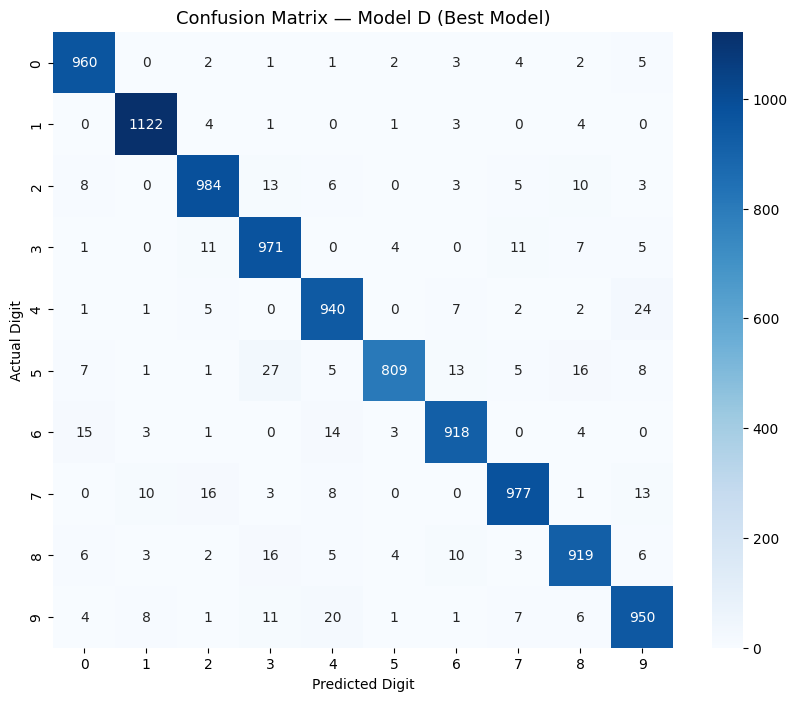

In [ ]:
# Confusion matrix for best model (Model D)
cm = confusion_matrix(y_test, y_pred_D)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.title('Confusion Matrix — Model D (Best Model)', fontsize=13)
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')
plt.show()

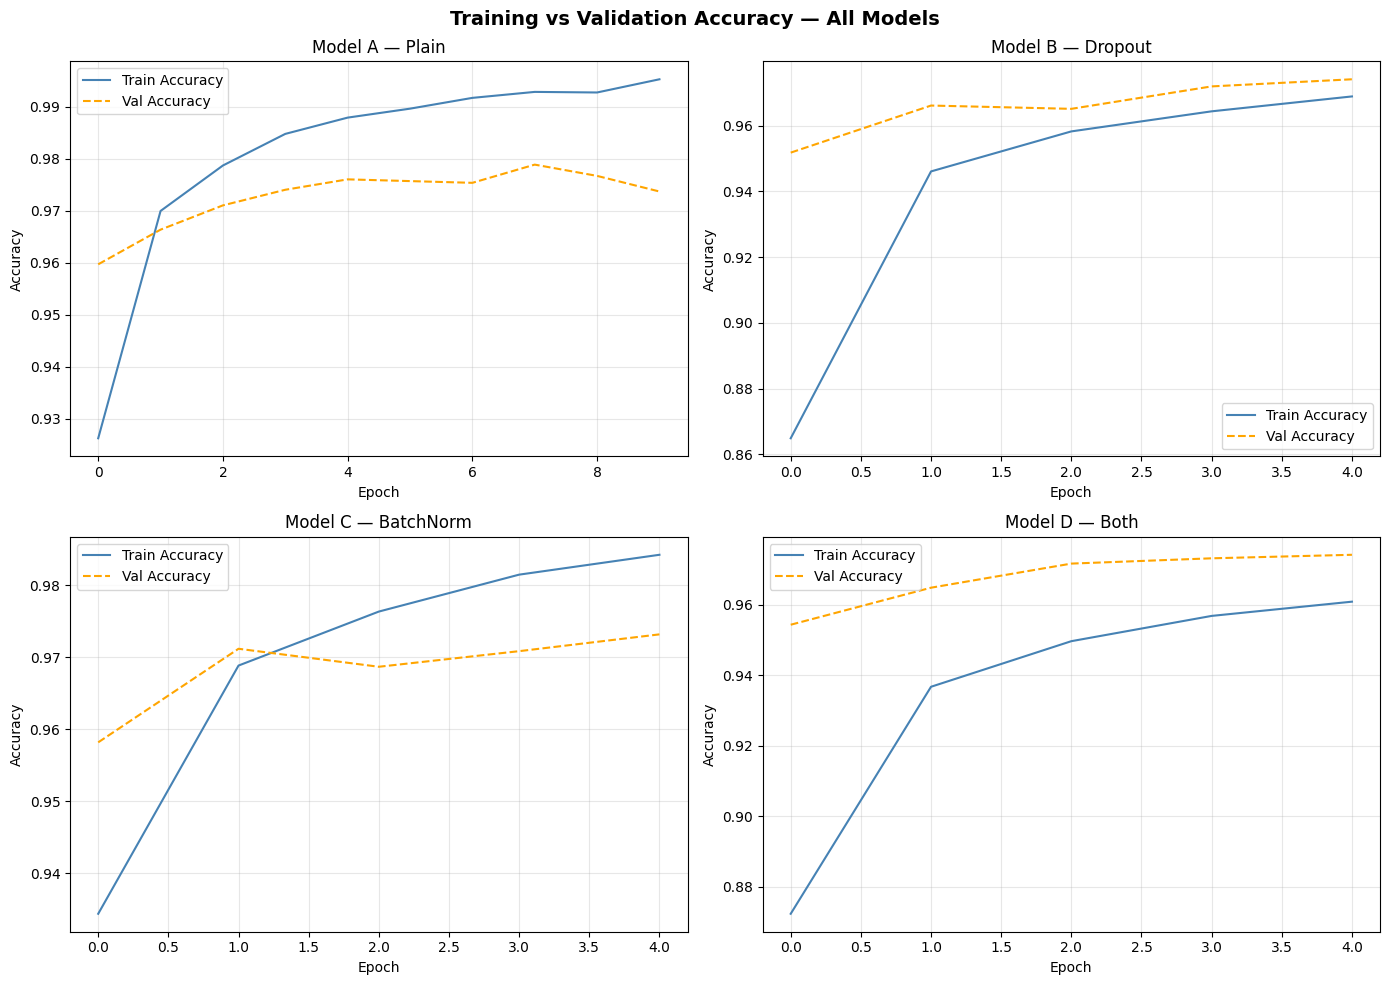

In [ ]:
# Plot training and validation accuracy for all four models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models_info = [
    (history_A, 'Model A — Plain',       axes[0,0]),
    (history_B, 'Model B — Dropout',     axes[0,1]),
    (history_C, 'Model C — BatchNorm',   axes[1,0]),
    (history_D, 'Model D — Both',        axes[1,1]),
]

for history, title, ax in models_info:
    ax.plot(history.history['accuracy'],
            label='Train Accuracy', color='steelblue')
    ax.plot(history.history['val_accuracy'],
            label='Val Accuracy', color='orange', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Accuracy — All Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Rebuild and retrain all four models fresh
# Fresh callbacks for EACH model separately

def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
    checkpoint = ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
    return [early_stop, checkpoint]

print("Callback function ready!")

Callback function ready!


In [ ]:
# Rebuild models fresh (training already changed their weights)
model_A = build_model(False, False, 'Model_A_Plain')
model_B = build_model(True,  False, 'Model_B_Dropout')
model_C = build_model(False, True,  'Model_C_BatchNorm')
model_D = build_model(True,  True,  'Model_D_Both')

training_results = {}

for model, name in [
    (model_A, 'Model A'),
    (model_B, 'Model B'),
    (model_C, 'Model C'),
    (model_D, 'Model D')
]:
    print(f"\nTraining {name}...")
    start = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=get_callbacks(),   # fresh callbacks every time
        verbose=0
    )

    elapsed = time.time() - start
    training_results[name] = {
        'history': history,
        'time'   : elapsed
    }
    print(f"{name} done in {elapsed:.1f}s — val_accuracy: {max(history.history['val_accuracy']):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training Model A...
Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.
Model A done in 73.9s — val_accuracy: 0.9777

Training Model B...
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 13.
Model B done in 113.2s — val_accuracy: 0.9808

Training Model C...
Epoch 13: early stopping
Restoring model weights from the end of the best epoch: 8.
Model C done in 95.0s — val_accuracy: 0.9812

Training Model D...
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 22.
Model D done in 195.1s — val_accuracy: 0.9833


In [ ]:
# Save histories separately for easy access
history_A = training_results['Model A']['history']
history_B = training_results['Model B']['history']
history_C = training_results['Model C']['history']
history_D = training_results['Model D']['history']

print("Histories saved!")
print("Now re-run the plot cells from Step 7 and they will work correctly.")

Histories saved!
Now re-run the plot cells from Step 7 and they will work correctly.


In [ ]:
# Function to run one experiment and return metrics
def run_experiment(hidden_layers, dropout_rate, batch_size,
                   learning_rate, optimizer_name):

    # Build model
    model = keras.Sequential()

    # Add hidden layers
    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(layers.Dense(units, activation='relu',
                                   input_shape=(784,)))
        else:
            model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    # Output layer
    model.add(layers.Dense(10, activation='softmax'))

    # Choose optimizer
    if optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate,
                                   momentum=0.9)

    # Compile
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train
    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(monitor='val_loss',
                                 patience=3,
                                 restore_best_weights=True)],
        verbose=0
    )
    elapsed = time.time() - start

    # Evaluate
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')

    return acc, f1, elapsed

print("Experiment function ready!")

Experiment function ready!


In [ ]:
# This will take about 5-8 minutes
print("Running experiments... please wait\n")

exp_results = []

# Exp 1 — Baseline
acc, f1, t = run_experiment([256,128,64], 0.3, 64, 0.001, 'adam')
exp_results.append(['1. Baseline (Adam, lr=0.001, [256,128,64], drop=0.3, batch=64)', acc, f1, t])
print("Experiment 1 done ✓")

# Exp 2 — Higher learning rate
acc, f1, t = run_experiment([256,128,64], 0.3, 64, 0.01, 'adam')
exp_results.append(['2. Higher lr=0.01', acc, f1, t])
print("Experiment 2 done ✓")

# Exp 3 — Lower learning rate
acc, f1, t = run_experiment([256,128,64], 0.3, 64, 0.0001, 'adam')
exp_results.append(['3. Lower lr=0.0001', acc, f1, t])
print("Experiment 3 done ✓")

# Exp 4 — Deeper network
acc, f1, t = run_experiment([512,256,128,64], 0.3, 64, 0.001, 'adam')
exp_results.append(['4. Deeper [512,256,128,64]', acc, f1, t])
print("Experiment 4 done ✓")

# Exp 5 — Shallower network
acc, f1, t = run_experiment([128,64], 0.3, 64, 0.001, 'adam')
exp_results.append(['5. Shallower [128,64]', acc, f1, t])
print("Experiment 5 done ✓")

# Exp 6 — Higher dropout
acc, f1, t = run_experiment([256,128,64], 0.5, 64, 0.001, 'adam')
exp_results.append(['6. Higher dropout=0.5', acc, f1, t])
print("Experiment 6 done ✓")

# Exp 7 — No dropout
acc, f1, t = run_experiment([256,128,64], 0.0, 64, 0.001, 'adam')
exp_results.append(['7. No dropout=0.0', acc, f1, t])
print("Experiment 7 done ✓")

# Exp 8 — Larger batch
acc, f1, t = run_experiment([256,128,64], 0.3, 128, 0.001, 'adam')
exp_results.append(['8. Larger batch=128', acc, f1, t])
print("Experiment 8 done ✓")

# Exp 9 — Smaller batch
acc, f1, t = run_experiment([256,128,64], 0.3, 32, 0.001, 'adam')
exp_results.append(['9. Smaller batch=32', acc, f1, t])
print("Experiment 9 done ✓")

# Exp 10 — RMSProp optimizer
acc, f1, t = run_experiment([256,128,64], 0.3, 64, 0.001, 'rmsprop')
exp_results.append(['10. RMSProp optimizer', acc, f1, t])
print("Experiment 10 done ✓")

# Exp 11 — SGD optimizer
acc, f1, t = run_experiment([256,128,64], 0.3, 64, 0.01, 'sgd')
exp_results.append(['11. SGD optimizer', acc, f1, t])
print("Experiment 11 done ✓")

print("\nAll experiments complete!")

Running experiments... please wait

Experiment 1 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 2 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 3 done ✓


...

Experiment 9 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 10 done ✓


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 11 done ✓

All experiments complete!


In [ ]:
# Clean comparison table
exp_df = pd.DataFrame(exp_results,
                      columns=['Experiment', 'Accuracy', 'F1-Score', 'Time(s)'])

print("=" * 75)
print(f"{'Experiment':<45} {'Accuracy':>9} {'F1':>8} {'Time':>8}")
print("=" * 75)
for _, row in exp_df.iterrows():
    print(f"{row['Experiment']:<45} {row['Accuracy']:>9.4f} "
          f"{row['F1-Score']:>8.4f} {row['Time(s)']:>7.1f}s")
print("=" * 75)

# Find best
best = exp_df.loc[exp_df['Accuracy'].idxmax()]
print(f"\nBest experiment : {best['Experiment']}")
print(f"Accuracy        : {best['Accuracy']:.4f}")
print(f"F1-Score        : {best['F1-Score']:.4f}")
print(f"Training time   : {best['Time(s)']:.1f}s")

Experiment                                     Accuracy       F1     Time
1. Baseline (Adam, lr=0.001, [256,128,64], drop=0.3, batch=64)    0.9791   0.9791    85.0s
2. Higher lr=0.01                                0.9777   0.9777   113.9s
3. Lower lr=0.0001                               0.9788   0.9788   134.1s
4. Deeper [512,256,128,64]                       0.9804   0.9804   138.7s
5. Shallower [128,64]                            0.9757   0.9757    44.8s
6. Higher dropout=0.5                            0.9789   0.9789   141.2s
7. No dropout=0.0                                0.9750   0.9750    63.9s
8. Larger batch=128                              0.9789   0.9789    51.2s
9. Smaller batch=32                              0.9784   0.9784   151.7s
10. RMSProp optimizer                            0.9831   0.9831   118.6s
11. SGD optimizer                                0.9833   0.9833   112.1s

Best experiment : 11. SGD optimizer
Accuracy        : 0.9833
F1-Score        : 0.9833
Training